## 1. Mount Google Drive

This step connects your Google Colab environment to your Google Drive, allowing the notebook to access your datasets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Install Required Libraries

We'll install `ultralytics` for YOLOv8, `opencv-python` for image processing, and `matplotlib`/`numpy` for plotting and data manipulation.

In [ ]:
!pip install ultralytics opencv-python matplotlib numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.9 MB/s eta 0:00:00


## 3. Define Dataset Paths and Initialize YOLOv8 Model

Here, we define the paths to your datasets on Google Drive and initialize a pre-trained YOLOv8n model, which will be fine-tuned on your custom data.

In [ ]:
import os
from ultralytics import YOLO

# Define dataset paths
HELMET_DETECTION_DATASET_PATH = '/content/drive/MyDrive/Helmet-Detection.v1i.yolov8'
LICENSE_PLATE_DATASET_PATH = '/content/drive/MyDrive/license_plate_dataset' # Not directly used for training in this notebook

# Initialize a YOLOv8n model (a small, fast model, good starting point for transfer learning)
# You can choose other models like 'yolov8m.pt', 'yolov8l.pt' for better accuracy if computational resources allow.
model = YOLO('yolov8n.pt')

print(f"Helmet Detection Dataset Path: {HELMET_DETECTION_DATASET_PATH}")
print(f"License Plate Dataset Path (not used for training in this notebook): {LICENSE_PLATE_DATASET_PATH}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Helmet Detection Dataset Path: /content/drive/MyDrive/Helmet-Detection.v1i.yolov8
License Plate Dataset Path (not used for training in this notebook): /content/drive/MyDrive/license_plate_dataset


In [ ]:
# Train the model
# Adjust `epochs`, `imgsz`, and `batch` according to your dataset size and computational resources.
# 'name' parameter helps organize runs in the 'runs/detect' directory.
results = model.train(data=os.path.join(HELMET_DETECTION_DATASET_PATH, 'data.yaml'),
                      epochs=50,  # Recommended to start with 50-100 epochs, adjust as needed
                      imgsz=640,  # Image size, typically 640 for YOLOv8n/s
                      batch=16,   # Batch size, depends on GPU memory
                      name='helmet_detection_yolov8')

print(f"Training results saved to: {results.save_dir}")
print(f"Best trained weights (best.pt) are located at: {os.path.join(results.save_dir, 'weights', 'best.pt')}")
print(f"Training graphs (results.png) are located at: {os.path.join(results.save_dir, 'results.png')}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Helmet-Detection.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_detection_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

## 5. Evaluate the Model

After training, it's important to evaluate the model's performance on a validation set. This step calculates metrics such as precision, recall, and mean Average Precision (mAP).

In [ ]:
import os
from ultralytics import YOLO

# Load the best trained model for evaluation
best_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')
trained_model = YOLO(best_model_path)

# Evaluate the model on the validation set
metrics = trained_model.val()

# Print detailed evaluation metrics
print("\n--- Evaluation Metrics ---")
print(f"Precision: {metrics.results_dict.get('metrics/precision(B)', 'N/A'): .4f}")
print(f"Recall: {metrics.results_dict.get('metrics/recall(B)', 'N/A'): .4f}")
print(f"mAP50: {metrics.results_dict.get('metrics/mAP50(B)', 'N/A'): .4f}") # mAP at IoU threshold of 0.5
print(f"mAP50-95: {metrics.results_dict.get('metrics/mAP50-95(B)', 'N/A'): .4f}") # mAP averaged over IoU thresholds from 0.5 to 0.95

# You can also print per-class metrics if available
if hasattr(metrics, 'confusion_matrix') and metrics.confusion_matrix is not None:
    print("\nPer-Class mAP:")
    for i, ap_value in enumerate(metrics.box.ap):
        if i < len(trained_model.names):
            print(f"  {trained_model.names[i]}: {ap_value:.4f}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 4.0±7.5 ms, read: 15.8±14.0 MB/s, size: 39.8 KB)
val: Scanning /content/drive/MyDrive/Helmet-Detection.v1i.yolov8/valid/labels.cache... 123 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 32.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.4it/s 3.4s
                   all        123        234      0.672      0.743      0.751      0.441
           with_helmet         81        147      0.743       0.83      0.861      0.541
        without_helmet         49         87      0.601      0.655      0.641       0.34
Speed: 4.4ms preprocess, 5.6ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /content/runs/detect/val

--- Evaluation Metrics ---
Precision:  0.6722
Recall:  0.7426
mAP50:  0.7

## 6. Display YOLO Training Graphs

The `results.png` file generated during training provides a visual summary of the model's performance over epochs.

Displaying training results from: /content/runs/detect/helmet_detection_yolov8/results.png


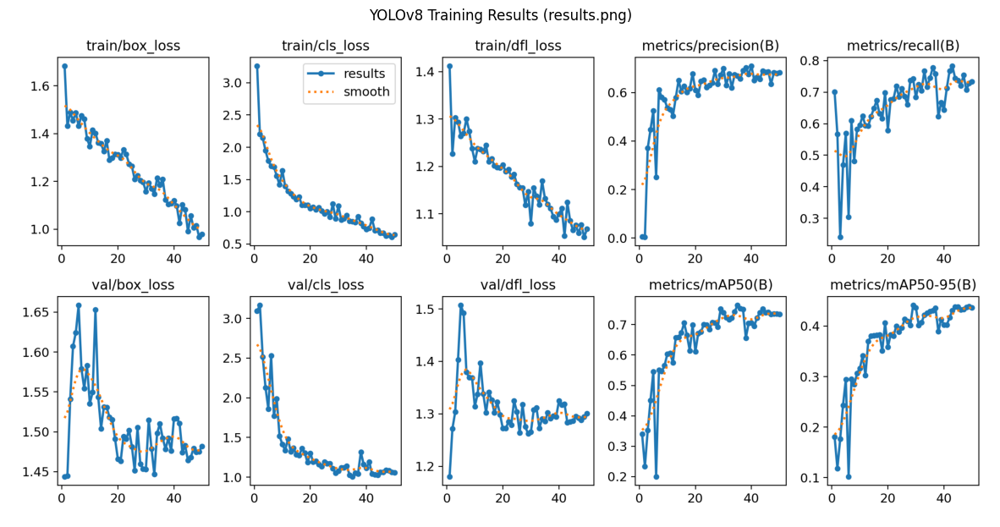

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

# Define the training run name (must match the name used in model.train)
run_name = 'helmet_detection_yolov8'
# Define the base directory where Ultralytics saves runs
base_save_dir = '/content/runs/detect'
# Construct the path to the results.png file
results_img_path = os.path.join(base_save_dir, run_name, 'results.png')

if os.path.exists(results_img_path):
    print(f"Displaying training results from: {results_img_path}")
    img = cv2.imread(results_img_path)
    if img is not None:
        # OpenCV reads images in BGR format, matplotlib expects RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(15, 10))
        plt.imshow(img_rgb)
        plt.axis('off') # Hide axes
        plt.title('YOLOv8 Training Results (results.png)')
        plt.show()
    else:
        print(f"Error: Could not load image from {results_img_path}. It might be corrupted or not a valid image.")
else:
    print(f"Training results image not found at {results_img_path}. Please ensure training completed successfully and check the path.")

## 7. Run Inference on Sample Images & Visualize Results

This section demonstrates how to use the trained model to detect objects in new images. It also implements the pipeline logic: first detect `helmet` and `without_helmet` riders, and if a `without_helmet` rider is detected, the presence of `number_plate` detections becomes particularly relevant. All detected objects are displayed with bounding boxes, and the output images are saved.

Error loading number plate model from /content/drive/MyDrive/license_plate_dataset/runs/detect/number_plate_yolov8/weights/best.pt: [Errno 2] No such file or directory: '/content/drive/MyDrive/license_plate_dataset/runs/detect/number_plate_yolov8/weights/best.pt'
Please ensure the number plate detection model is trained and its 'best.pt' weights are available at the specified path.
Output images will be saved to: /content/inference_output_violation_pipeline

Running inference on 5 sample images from the validation set...
Helmet Detection Model classes: {0: 'with_helmet', 1: 'without_helmet'}
Number Plate Detection Model classes: {}

--- Processing image 1/5: BikesHelmets511_png.rf.f552b6cd9d1bccfe356d18883b3f4f36.jpg ---
  No 'without_helmet' rider detected. Number plate detection skipped.


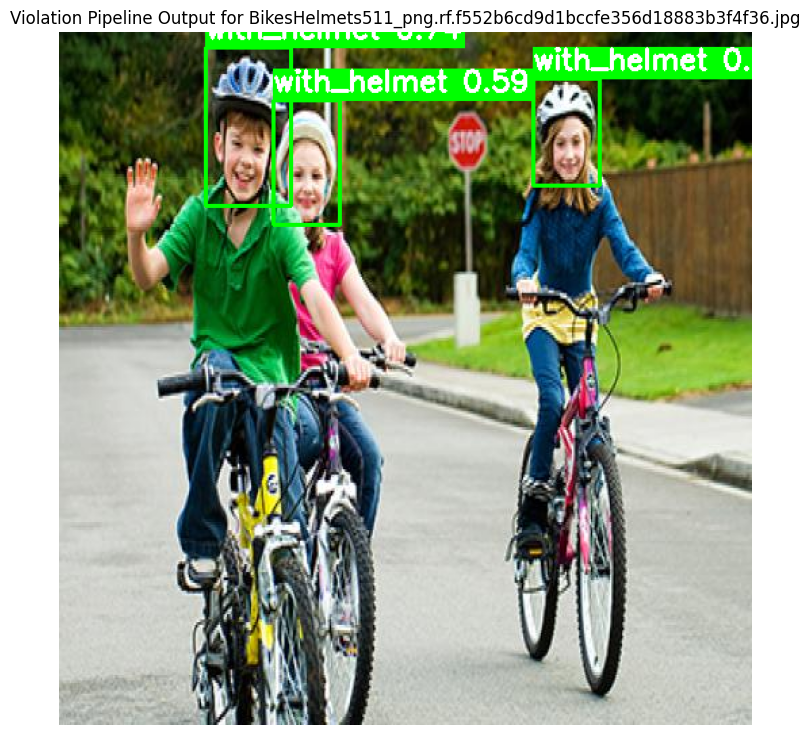

Violation pipeline output saved to: inference_output_violation_pipeline/violation_detected_BikesHelmets511_png.rf.f552b6cd9d1bccfe356d18883b3f4f36.jpg

--- Processing image 2/5: BikesHelmets420_png.rf.031b1a3e42e1cc7ad32f98856268ab9c.jpg ---
  No 'without_helmet' rider detected. Number plate detection skipped.


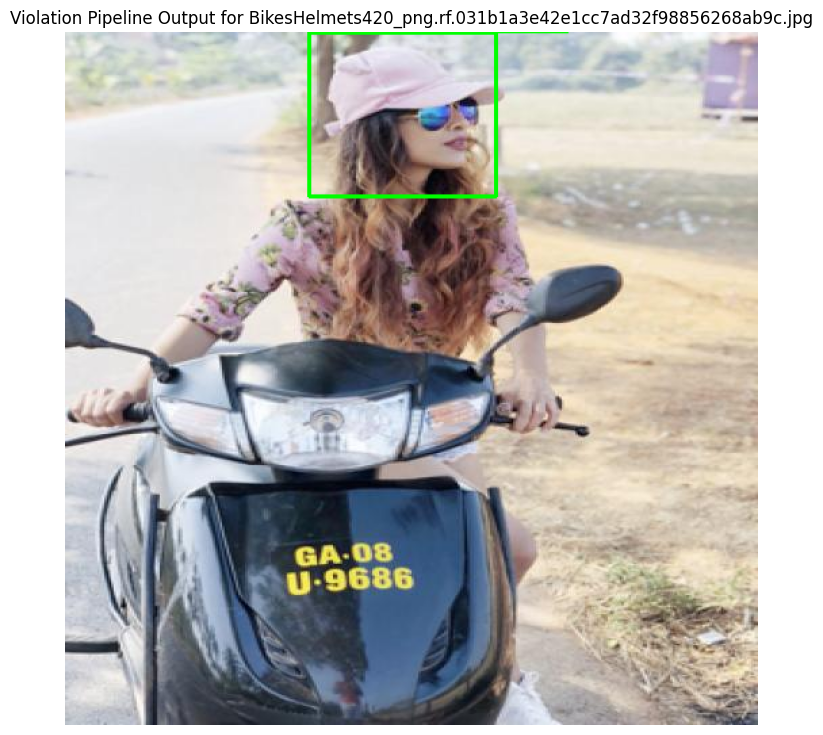

Violation pipeline output saved to: inference_output_violation_pipeline/violation_detected_BikesHelmets420_png.rf.031b1a3e42e1cc7ad32f98856268ab9c.jpg

--- Processing image 3/5: BikesHelmets726_png.rf.c9f5245a21b513b63d1af3dfb37e380d.jpg ---
  No 'without_helmet' rider detected. Number plate detection skipped.


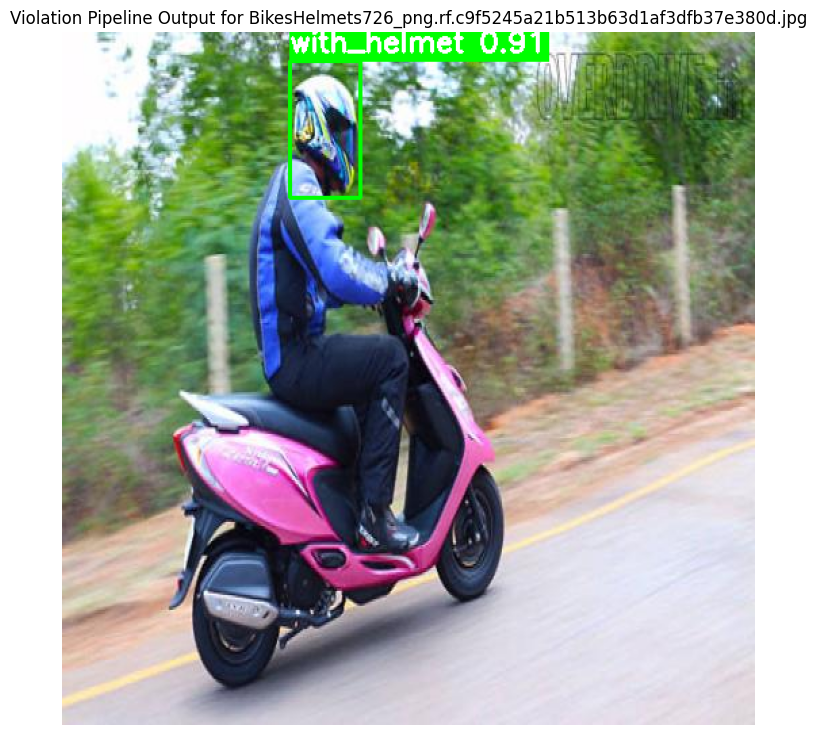

Violation pipeline output saved to: inference_output_violation_pipeline/violation_detected_BikesHelmets726_png.rf.c9f5245a21b513b63d1af3dfb37e380d.jpg

--- Processing image 4/5: BikesHelmets1_png.rf.9a5c8c719858c2bc0c6f7108f5e60d85.jpg ---
  No 'without_helmet' rider detected. Number plate detection skipped.


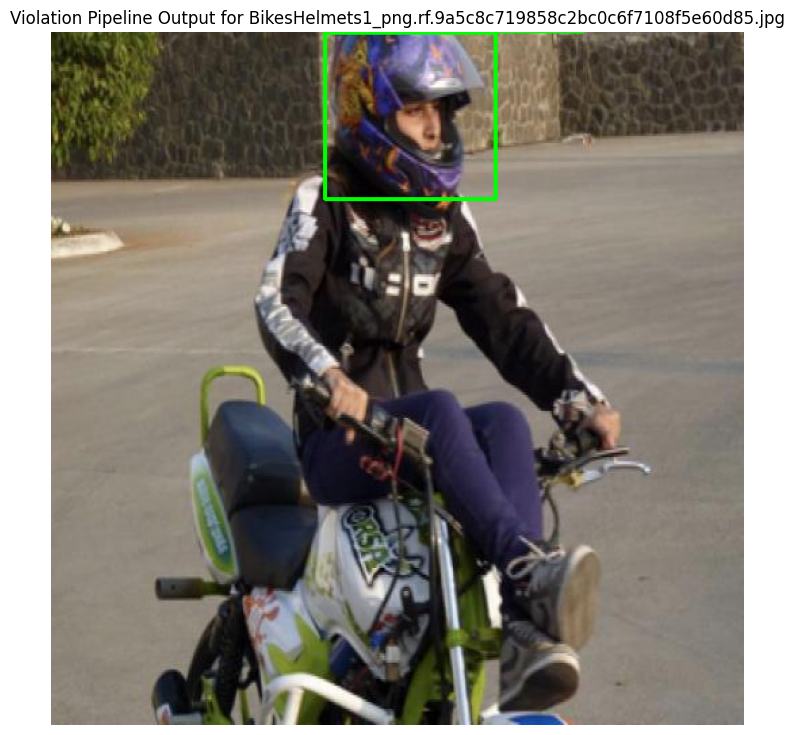

Violation pipeline output saved to: inference_output_violation_pipeline/violation_detected_BikesHelmets1_png.rf.9a5c8c719858c2bc0c6f7108f5e60d85.jpg

--- Processing image 5/5: BikesHelmets155_png.rf.e5e8a3c7e8f0d349d8c8f0d636a3b293.jpg ---
  No 'without_helmet' rider detected. Number plate detection skipped.


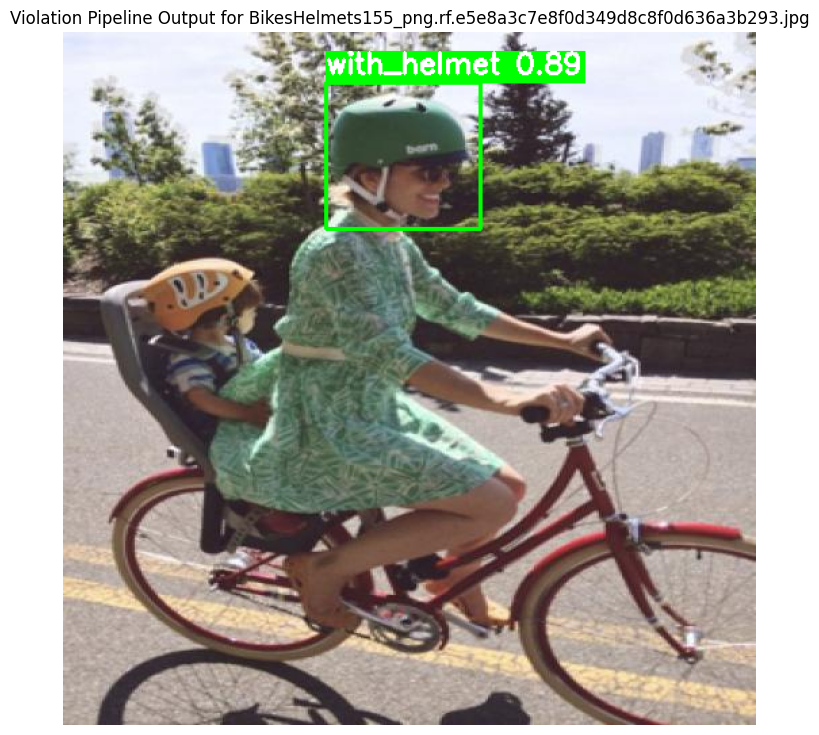

Violation pipeline output saved to: inference_output_violation_pipeline/violation_detected_BikesHelmets155_png.rf.e5e8a3c7e8f0d349d8c8f0d636a3b293.jpg

All violation pipeline outputs saved to the 'inference_output_violation_pipeline' directory.


In [ ]:
import glob
import random
import shutil
import os
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# Define the training run name for helmet detection
HELMET_MODEL_RUN_NAME = 'helmet_detection_yolov8'
# Define the base directory where Ultralytics saves runs
BASE_SAVE_DIR = '/content/runs/detect'

# Construct the path to the best weights for the HELMET detection model
best_helmet_model_path = os.path.join(BASE_SAVE_DIR, HELMET_MODEL_RUN_NAME, 'weights', 'best.pt')

# Load the best trained HELMET detection model
helmet_model = YOLO(best_helmet_model_path)

# --- Define and Load the NUMBER PLATE detection model ---
# IMPORTANT: This assumes you have already trained a separate YOLOv8 model for number plate detection
# and its weights are saved in a similar structure within your license plate dataset path.
# If you haven't trained this model yet, you would need to do so first.
NUMBER_PLATE_MODEL_PATH = '/content/drive/MyDrive/license_plate_dataset/runs/detect/number_plate_yolov8/weights/best.pt' # Adjust this path as needed

# Load the NUMBER PLATE detection model
# If the path above does not exist or the model is not trained yet, this will fail.
try:
    number_plate_model = YOLO(NUMBER_PLATE_MODEL_PATH)
    print(f"Number Plate Detection model loaded from: {NUMBER_PLATE_MODEL_PATH}")
except Exception as e:
    print(f"Error loading number plate model from {NUMBER_PLATE_MODEL_PATH}: {e}")
    print("Please ensure the number plate detection model is trained and its 'best.pt' weights are available at the specified path.")
    # Exit or handle the error appropriately if the number plate model is critical


# Create a directory to save inference results
output_dir = 'inference_output_violation_pipeline'
os.makedirs(output_dir, exist_ok=True)
print(f"Output images will be saved to: {os.path.abspath(output_dir)}")

# Path to validation images (assuming your dataset structure has 'valid/images')
HELMET_DETECTION_DATASET_PATH = '/content/drive/MyDrive/Helmet-Detection.v1i.yolov8'
val_image_path = os.path.join(HELMET_DETECTION_DATASET_PATH, 'valid', 'images')

# Get a list of all image files in the validation set
sample_images = glob.glob(os.path.join(val_image_path, '*.jpg')) + \
                glob.glob(os.path.join(val_image_path, '*.jpeg')) + \
                glob.glob(os.path.join(val_image_path, '*.png'))

# Select at least 3 random sample images for inference
num_samples_to_infer = min(5, len(sample_images)) # Increased to 5 for more examples, or take all if less than 5
if num_samples_to_infer == 0:
    print(f"No images found in {val_image_path} for inference. Please check your dataset path and structure.")
else:
    random_sample_images = random.sample(sample_images, num_samples_to_infer)
    print(f"\nRunning inference on {num_samples_to_infer} sample images from the validation set...")

    # Get class names from the helmet model for easier interpretation
    helmet_class_names = helmet_model.names
    print(f"Helmet Detection Model classes: {helmet_class_names}")

    # Get class names from the number plate model
    number_plate_class_names = number_plate_model.names if 'number_plate_model' in locals() else {}
    print(f"Number Plate Detection Model classes: {number_plate_class_names}")

    for i, img_path in enumerate(random_sample_images):
        print(f"\n--- Processing image {i+1}/{num_samples_to_infer}: {os.path.basename(img_path)} ---")

        # Load the original image
        original_img = cv2.imread(img_path)
        if original_img is None:
            print(f"Warning: Could not load image {img_path}. Skipping.")
            continue

        display_img = original_img.copy() # Image to draw on

        # Step 1: Run helmet detection on the input image
        helmet_results = helmet_model(img_path, conf=0.25, verbose=False) # conf threshold can be adjusted

        all_detections_to_draw = [] # To store detections from both models
        has_without_helmet_rider = False

        # Process helmet detection results
        for res in helmet_results:
            if res.boxes is not None and len(res.boxes) > 0:
                for box in res.boxes:
                    cls_id = int(box.cls[0])
                    conf = float(box.conf[0])
                    class_name = helmet_class_names[cls_id]

                    if class_name == 'without_helmet':
                        has_without_helmet_rider = True
                        # Add without_helmet detection to the list for drawing
                        all_detections_to_draw.append({
                            'box': box.xyxy[0].cpu().numpy(),
                            'class': class_name,
                            'conf': conf,
                            'color': (0, 0, 255) # Red for violation
                        })
                    elif class_name == 'with_helmet':
                        # Add with_helmet detection to the list for drawing
                        all_detections_to_draw.append({
                            'box': box.xyxy[0].cpu().numpy(),
                            'class': class_name,
                            'conf': conf,
                            'color': (0, 255, 0) # Green for compliance
                        })
                    # You can add 'rider' class if it's explicitly part of your helmet model's output

        # Step 3 & 4: If 'without_helmet' is detected, run number plate detection
        if has_without_helmet_rider and 'number_plate_model' in locals():
            print("  'without_helmet' rider detected. Running number plate detection...")
            number_plate_results = number_plate_model(img_path, conf=0.25, verbose=False) # conf threshold can be adjusted

            for res_lp in number_plate_results:
                if res_lp.boxes is not None and len(res_lp.boxes) > 0:
                    for box_lp in res_lp.boxes:
                        cls_id_lp = int(box_lp.cls[0])
                        conf_lp = float(box_lp.conf[0])
                        class_name_lp = number_plate_class_names[cls_id_lp]

                        if class_name_lp == 'number_plate': # Ensure it's the number plate class
                            # Add number plate detection to the list for drawing
                            all_detections_to_draw.append({
                                'box': box_lp.xyxy[0].cpu().numpy(),
                                'class': class_name_lp,
                                'conf': conf_lp,
                                'color': (255, 0, 0) # Blue for number plate
                            })
        elif has_without_helmet_rider and 'number_plate_model' not in locals():
            print("  'without_helmet' rider detected, but number plate model not loaded.")
        else:
            print("  No 'without_helmet' rider detected. Number plate detection skipped.")


        # Step 5: Draw bounding boxes for both without_helmet rider and number plate
        # and Step 6: Display the final output image with both detections
        for det in all_detections_to_draw:
            x1, y1, x2, y2 = map(int, det['box'])
            label = f"{det['class']} {det['conf']:.2f}"
            color = det['color']
            thickness = 2

            # Draw rectangle
            cv2.rectangle(display_img, (x1, y1), (x2, y2), color, thickness)

            # Draw label background
            (text_width, text_height), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
            cv2.rectangle(display_img, (x1, y1 - text_height - baseline), (x1 + text_width, y1), color, -1)
            cv2.putText(display_img, label, (x1, y1 - baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        # Convert to RGB for matplotlib display
        display_img_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)

        # Display the annotated image
        plt.figure(figsize=(12, 9))
        plt.imshow(display_img_rgb)
        plt.title(f"Violation Pipeline Output for {os.path.basename(img_path)}")
        plt.axis('off')
        plt.show()

        # Save the final output image
        output_img_name = f"violation_detected_{os.path.basename(img_path)}"
        output_img_path = os.path.join(output_dir, output_img_name)
        cv2.imwrite(output_img_path, display_img) # Save in BGR format as OpenCV prefers
        print(f"Violation pipeline output saved to: {output_img_path}")

    print(f"\nAll violation pipeline outputs saved to the '{output_dir}' directory.")

In [ ]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

LICENSE_PLATE_DATASET_PATH = '/content/drive/MyDrive/license_plate_dataset'

xml_annotations_path = os.path.join(LICENSE_PLATE_DATASET_PATH, 'annotations')
images_path = os.path.join(LICENSE_PLATE_DATASET_PATH, 'images')
yolo_labels_output_path = os.path.join(LICENSE_PLATE_DATASET_PATH, 'labels') # Overwrite existing or create new

# Create the output directory for YOLO labels if it doesn't exist
os.makedirs(yolo_labels_output_path, exist_ok=True)

# Define class names (based on problem description, only 'number_plate')
# Corrected: mapping 'licence' to 0 based on the warning messages.
class_names = {'licence': 0}

def convert_xml_to_yolo(xml_file_path, image_file_path, output_dir, class_dict):
    try:
        tree = ET.parse(xml_file_path)
        root = tree.getroot()

        # Get image dimensions
        img = Image.open(image_file_path)
        img_width, img_height = img.size

        # Output YOLO label file
        label_file_name = os.path.splitext(os.path.basename(xml_file_path))[0] + '.txt'
        label_file_path = os.path.join(output_dir, label_file_name)

        # Flag to check if any objects were written to the label file
        has_objects = False
        with open(label_file_path, 'w') as f:
            for obj in root.findall('object'):
                obj_name = obj.find('name').text
                if obj_name in class_dict: # Only process relevant classes
                    class_id = class_dict[obj_name]
                    bbox = obj.find('bndbox')
                    xmin = float(bbox.find('xmin').text)
                    ymin = float(bbox.find('ymin').text)
                    xmax = float(bbox.find('xmax').text)
                    ymax = float(bbox.find('ymax').text)

                    # Convert to YOLO format (normalized x_center y_center width height)
                    x_center = (xmin + xmax) / 2 / img_width
                    y_center = (ymin + ymax) / 2 / img_height
                    width = (xmax - xmin) / img_width
                    height = (ymax - ymin) / img_height

                    f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
                    has_objects = True
                else:
                    print(f"Warning: Unknown object class '{obj_name}' in {xml_file_path}. Skipping.")

        # If no objects were written, remove the empty label file
        if not has_objects:
            os.remove(label_file_path)

    except Exception as e:
        print(f"Error processing {xml_file_path}: {e}")

print(f"Starting XML to YOLO label conversion from {xml_annotations_path} to {yolo_labels_output_path}")

processed_count = 0
error_count = 0
for xml_file in os.listdir(xml_annotations_path):
    if xml_file.endswith('.xml'):
        xml_file_path = os.path.join(xml_annotations_path, xml_file)
        image_base_name = os.path.splitext(xml_file)[0] # Assuming image name matches XML base name

        # Try to find corresponding image with common extensions
        image_found = False
        for ext in ['.jpg', '.jpeg', '.png']:
            potential_image_path = os.path.join(images_path, image_base_name + ext)
            if os.path.exists(potential_image_path):
                convert_xml_to_yolo(xml_file_path, potential_image_path, yolo_labels_output_path, class_names)
                processed_count += 1
                image_found = True
                break
        if not image_found:
            print(f"Warning: Image not found for {xml_file} in {images_path}. Skipping XML.")
            error_count += 1

print(f"Conversion complete. Processed {processed_count} XML files, {error_count} skipped due to missing images.")
print(f"YOLO format labels saved to: {yolo_labels_output_path}")

# Now, the original dataset splitting logic needs to be re-run.
# The next step will be to re-execute the cell that performs the train/val split.

Starting XML to YOLO label conversion from /content/drive/MyDrive/license_plate_dataset/annotations to /content/drive/MyDrive/license_plate_dataset/labels
Conversion complete. Processed 433 XML files, 0 skipped due to missing images.
YOLO format labels saved to: /content/drive/MyDrive/license_plate_dataset/labels


## STEP 2.1: Convert XML Annotations to YOLO Format

This step will read the XML annotation files from the `annotations` directory, extract bounding box information, and convert it into the YOLO `.txt` format. These new `.txt` files will be saved in the `labels` directory, overwriting any existing (likely empty) ones, to prepare for proper dataset splitting.

## Re-run STEP 2: Prepare Dataset and Create `data.yaml` for Number Plate Detection

Now that the XML annotations have been converted to YOLO format, we need to re-run the dataset splitting to populate the `train/labels` and `valid/labels` directories correctly.

## STEP 3: Train Number Plate YOLOv8 Model

Now we will train a YOLOv8 model specifically for number plate detection using the `plate_data.yaml` we just created. We'll use a `yolov8n.pt` pre-trained model as a starting point for transfer learning.

In [ ]:
import os
from ultralytics import YOLO

# Define the path to your license plate dataset (used to construct data.yaml path)
LICENSE_PLATE_DATASET_PATH = '/content/drive/MyDrive/license_plate_dataset'
# Path to the data.yaml file we just created
PLATE_DATA_YAML_PATH = os.path.join(LICENSE_PLATE_DATASET_PATH, 'plate_data.yaml')

# Initialize a YOLOv8n model (small, fast, good for transfer learning)
plate_model_trainer = YOLO('yolov8n.pt')

# Train the number plate model
# Adjust `epochs`, `imgsz`, and `batch` as needed. Using 30 epochs as requested.
plate_results = plate_model_trainer.train(
    data=PLATE_DATA_YAML_PATH,
    epochs=30,  # Training for 30 epochs as requested
    imgsz=640,  # Image size
    batch=16,   # Batch size, adjust based on GPU memory
    name='plate_detection_yolov8' # Name for this specific training run
)

print(f"Number Plate Training results saved to: {plate_results.save_dir}")
print(f"Best trained number plate weights (best.pt) are located at: {os.path.join(plate_results.save_dir, 'weights', 'best.pt')}")
print(f"Training graphs (results.png) for number plate model are located at: {os.path.join(plate_results.save_dir, 'results.png')}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/license_plate_dataset/plate_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_detection_yolov83, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

In [ ]:
import os

# Define the training run name (must match the name used in plate_model_trainer.train)
PLATE_MODEL_RUN_NAME = 'plate_detection_yolov83' # Corrected run name
# Define the base directory where Ultralytics saves runs
BASE_SAVE_DIR = '/content/runs/detect'

# Construct the paths to the best.pt and last.pt files
best_plate_model_path = os.path.join(BASE_SAVE_DIR, PLATE_MODEL_RUN_NAME, 'weights', 'best.pt')
last_plate_model_path = os.path.join(BASE_SAVE_DIR, PLATE_MODEL_RUN_NAME, 'weights', 'last.pt')

print(f"Checking for trained model weights...")

if os.path.exists(best_plate_model_path):
    print(f"Best trained weights (best.pt) found at: {best_plate_model_path}")
else:
    print(f"Error: Best trained weights (best.pt) NOT found at: {best_plate_model_path}")
    print("Please ensure training completed successfully. You might need to adjust the 'name' parameter if it was changed during training.")

if os.path.exists(last_plate_model_path):
    print(f"Last trained weights (last.pt) found at: {last_plate_model_path}")
else:
    print(f"Error: Last trained weights (last.pt) NOT found at: {last_plate_model_path}")
    print("Please ensure training completed successfully.")


Checking for trained model weights...
Best trained weights (best.pt) found at: /content/runs/detect/plate_detection_yolov83/weights/best.pt
Last trained weights (last.pt) found at: /content/runs/detect/plate_detection_yolov83/weights/last.pt


In [ ]:
import os
from ultralytics import YOLO

# --- Load Helmet Detection Model ---
# Define the training run name for helmet detection (from previous steps)
HELMET_MODEL_RUN_NAME = 'helmet_detection_yolov8'
# Define the base directory where Ultralytics saves runs
BASE_SAVE_DIR = '/content/runs/detect'

# Construct the path to the best weights for the HELMET detection model
best_helmet_model_path = os.path.join(BASE_SAVE_DIR, HELMET_MODEL_RUN_NAME, 'weights', 'best.pt')

# Load the best trained HELMET detection model
try:
    helmet_model = YOLO(best_helmet_model_path)
    print(f"Helmet Detection model loaded from: {best_helmet_model_path}")
    print(f"Helmet Detection Model classes: {helmet_model.names}")
except Exception as e:
    print(f"Error loading helmet model from {best_helmet_model_path}: {e}")
    print("Please ensure the helmet detection model is trained and its 'best.pt' weights are available at the specified path.")


# --- Load Number Plate Detection Model ---
# Define the training run name for number plate detection (from previous step)
PLATE_MODEL_RUN_NAME = 'plate_detection_yolov83' # Corrected run name

# Construct the path to the best weights for the NUMBER PLATE detection model
best_plate_model_path = os.path.join(BASE_SAVE_DIR, PLATE_MODEL_RUN_NAME, 'weights', 'best.pt')

# Load the best trained NUMBER PLATE detection model
try:
    number_plate_model = YOLO(best_plate_model_path)
    print(f"Number Plate Detection model loaded from: {best_plate_model_path}")
    print(f"Number Plate Detection Model classes: {number_plate_model.names}")
except Exception as e:
    print(f"Error loading number plate model from {best_plate_model_path}: {e}")
    print("Please ensure the number plate detection model is trained and its 'best.pt' weights are available at the specified path.")


Helmet Detection model loaded from: /content/runs/detect/helmet_detection_yolov8/weights/best.pt
Helmet Detection Model classes: {0: 'with_helmet', 1: 'without_helmet'}
Number Plate Detection model loaded from: /content/runs/detect/plate_detection_yolov83/weights/best.pt
Number Plate Detection Model classes: {0: 'number_plate'}


## Full Violation Detection Pipeline with OCR

This cell executes the complete pipeline as requested by the user, integrating helmet detection, conditional number plate detection, OCR, visual annotation, and a comprehensive summary.

Installing Tesseract OCR and pytesseract...
Installation complete.
Helmet Detection model loaded from: /content/runs/detect/helmet_detection_yolov8/weights/best.pt
Helmet Detection Model classes: {0: 'with_helmet', 1: 'without_helmet'}
Number Plate Detection model loaded from: /content/runs/detect/plate_detection_yolov83/weights/best.pt
Number Plate Detection Model classes: {0: 'number_plate'}
Output images will be saved to: /content/final_violation_results

Running inference on 5 sample images from the validation set...

--- Processing image 1/5: BikesHelmets155_png.rf.e5e8a3c7e8f0d349d8c8f0d636a3b293.jpg ---
Violation pipeline output saved to: /content/final_violation_results/violation_detected_BikesHelmets155_png.rf.e5e8a3c7e8f0d349d8c8f0d636a3b293.jpg

--- Processing image 2/5: BikesHelmets721_png.rf.4baf45d5370de4292b6e005878063a50.jpg ---
Violation pipeline output saved to: /content/final_violation_results/violation_detected_BikesHelmets721_png.rf.4baf45d5370de4292b6e005878063a50

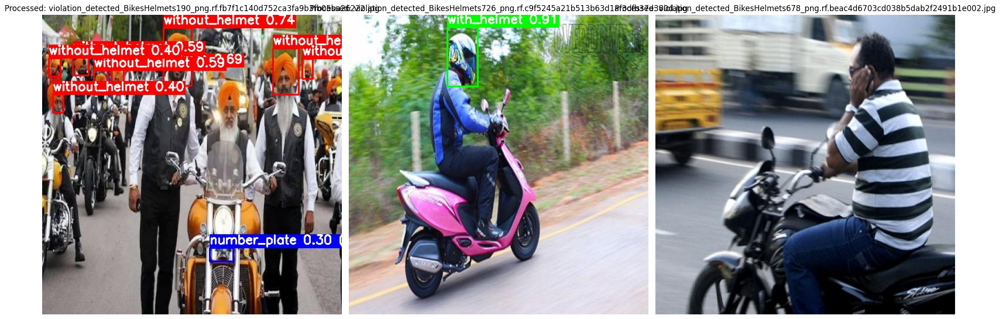

In [ ]:
import glob
import random
import shutil
import os
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# --- Install Tesseract OCR and pytesseract library if not already installed ---
# This ensures OCR functionality in the Colab environment
print("Installing Tesseract OCR and pytesseract...")
!sudo apt update > /dev/null 2>&1
!sudo apt install tesseract-ocr > /dev/null 2>&1
!pip install pytesseract > /dev/null 2>&1
print("Installation complete.")

# Import pytesseract AFTER installation
import pytesseract

# Point pytesseract to the tesseract executable (often not needed in Colab, but good practice)
pytesseract.pytesseract.tesseract_cmd = '/usr/bin/tesseract'

# --- Define Paths and Model Run Names ---
BASE_SAVE_DIR = '/content/runs/detect'
HELMET_MODEL_RUN_NAME = 'helmet_detection_yolov8'
PLATE_MODEL_RUN_NAME = 'plate_detection_yolov83' # Using the corrected run name

# --- Construct Model Paths ---
best_helmet_model_path = os.path.join(BASE_SAVE_DIR, HELMET_MODEL_RUN_NAME, 'weights', 'best.pt')
best_plate_model_path = os.path.join(BASE_SAVE_DIR, PLATE_MODEL_RUN_NAME, 'weights', 'best.pt')

# --- STEP 1: Load both trained YOLOv8 models ---
helmet_model = None
number_plate_model = None

try:
    helmet_model = YOLO(best_helmet_model_path)
    print(f"Helmet Detection model loaded from: {best_helmet_model_path}")
    print(f"Helmet Detection Model classes: {helmet_model.names}")
except Exception as e:
    print(f"Error loading helmet model from {best_helmet_model_path}: {e}")
    print("Please ensure the helmet detection model is trained and its 'best.pt' weights are available at the specified path. Aborting.")
    exit()

try:
    number_plate_model = YOLO(best_plate_model_path)
    print(f"Number Plate Detection model loaded from: {best_plate_model_path}")
    print(f"Number Plate Detection Model classes: {number_plate_model.names}")
except Exception as e:
    print(f"Error loading number plate model from {best_plate_model_path}: {e}")
    print("Please ensure the number plate detection model is trained and its 'best.pt' weights are available at the specified path. Aborting.")
    exit()

# --- Setup output directory (STEP 9) ---
output_dir = '/content/final_violation_results'
os.makedirs(output_dir, exist_ok=True)
print(f"Output images will be saved to: {os.path.abspath(output_dir)}")

# --- STEP 2: Take images from the validation folder ---
HELMET_DETECTION_DATASET_PATH = '/content/drive/MyDrive/Helmet-Detection.v1i.yolov8'
val_image_path = os.path.join(HELMET_DETECTION_DATASET_PATH, 'valid', 'images')

# Get a list of all image files in the validation set
sample_images = glob.glob(os.path.join(val_image_path, '*.jpg')) + \
                glob.glob(os.path.join(val_image_path, '*.jpeg')) + \
                glob.glob(os.path.join(val_image_path, '*.png'))

# Select 5 random sample images for inference
num_samples_to_infer = min(5, len(sample_images))
if num_samples_to_infer == 0:
    print(f"No images found in {val_image_path} for inference. Please check your dataset path and structure. Aborting.")
    exit()

random_sample_images = random.sample(sample_images, num_samples_to_infer)
print(f"\nRunning inference on {num_samples_to_infer} sample images from the validation set...")

# --- Initialize overall summary counters ---
total_riders_detected = 0
total_with_helmet = 0
total_without_helmet = 0
violator_vehicle_numbers = []

# --- Process each image ---
for i, img_path in enumerate(random_sample_images):
    print(f"\n--- Processing image {i+1}/{num_samples_to_infer}: {os.path.basename(img_path)} ---")

    original_img = cv2.imread(img_path)
    if original_img is None:
        print(f"Warning: Could not load image {img_path}. Skipping.")
        continue

    display_img = original_img.copy() # Image to draw on

    current_image_riders = 0
    current_image_with_helmet = 0
    current_image_without_helmet = 0
    has_without_helmet_violator = False
    all_detections_to_draw = [] # To store detections from both models

    # --- STEP 3: Run the helmet detection model ---
    helmet_inference_results = helmet_model(img_path, conf=0.25, verbose=False)

    for res in helmet_inference_results:
        if res.boxes is not None and len(res.boxes) > 0:
            for box in res.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                class_name = helmet_model.names[cls_id]

                if class_name in ['with_helmet', 'without_helmet']:
                    current_image_riders += 1
                    total_riders_detected += 1

                if class_name == 'with_helmet':
                    current_image_with_helmet += 1
                    total_with_helmet += 1
                    all_detections_to_draw.append({
                        'box': box.xyxy[0].cpu().numpy(),
                        'class': class_name,
                        'conf': conf,
                        'color': (0, 255, 0) # Green for compliance
                    })
                elif class_name == 'without_helmet':
                    current_image_without_helmet += 1
                    total_without_helmet += 1
                    has_without_helmet_violator = True
                    all_detections_to_draw.append({
                        'box': box.xyxy[0].cpu().numpy(),
                        'class': class_name,
                        'conf': conf,
                        'color': (0, 0, 255) # Red for violation
                    })

    # --- STEP 5: If a "without_helmet" rider is detected, run number plate detection ---
    if has_without_helmet_violator:
        print("  'without_helmet' rider detected. Running number plate detection...")
        number_plate_inference_results = number_plate_model(img_path, conf=0.25, verbose=False)

        for res_lp in number_plate_inference_results:
            if res_lp.boxes is not None and len(res_lp.boxes) > 0:
                for box_lp in res_lp.boxes:
                    cls_id_lp = int(box_lp.cls[0])
                    conf_lp = float(box_lp.conf[0])
                    class_name_lp = number_plate_model.names[cls_id_lp]

                    if class_name_lp == 'number_plate':
                        x1_lp, y1_lp, x2_lp, y2_lp = map(int, box_lp.xyxy[0].cpu().numpy())

                        # STEP 5: Crop the detected number plate region.
                        cropped_plate = original_img[y1_lp:y2_lp, x1_lp:x2_lp]

                        # STEP 6: Apply OCR using pytesseract on the cropped number plate image.
                        plate_text = pytesseract.image_to_string(cropped_plate, config='--psm 8') # psm 8 for single word/line
                        plate_text = ''.join(filter(str.isalnum, plate_text)).strip() # Clean text to alphanumeric

                        # STEP 7: Print the extracted number plate text.
                        if plate_text:
                            print(f"  Extracted Number Plate: {plate_text}")
                            violator_vehicle_numbers.append(plate_text)
                        else:
                            print("  No clear text extracted from number plate.")

                        # Store for drawing
                        all_detections_to_draw.append({
                            'box': box_lp.xyxy[0].cpu().numpy(),
                            'class': 'number_plate',
                            'conf': conf_lp,
                            'color': (255, 0, 0), # Blue for number plate
                            'text': plate_text # Store text for label
                        })

    # --- STEP 8: Draw bounding boxes on the image ---
    for det in all_detections_to_draw:
        x1, y1, x2, y2 = map(int, det['box'])
        label = f"{det['class']} {det['conf']:.2f}"
        if 'text' in det and det['text']:
            label += f" ({det['text']})"

        color = det['color']
        thickness = 2

        cv2.rectangle(display_img, (x1, y1), (x2, y2), color, thickness)
        (text_width, text_height), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(display_img, (x1, y1 - text_height - baseline), (x1 + text_width, y1), color, -1)
        cv2.putText(display_img, label, (x1, y1 - baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # Save the final output image (STEP 9)
    output_img_name = f"violation_detected_{os.path.basename(img_path)}"
    output_img_path = os.path.join(output_dir, output_img_name)
    cv2.imwrite(output_img_path, display_img) # Save in BGR format as OpenCV prefers
    print(f"Violation pipeline output saved to: {output_img_path}")

print(f"\nAll violation pipeline outputs saved to the '{output_dir}' directory.")

# --- STEP 10: Print a final summary ---
print("\n--------------------------------")
print(f"Total Riders Detected: {total_riders_detected}")
print(f"With Helmet: {total_with_helmet}")
print(f"Without Helmet: {total_without_helmet}")
print("--------------------------------")

# --- STEP 11: Print extracted number plates of violators ---
print("\nViolator Vehicle Numbers:")
if violator_vehicle_numbers:
    for idx, plate in enumerate(violator_vehicle_numbers):
        print(f"{idx+1}. {plate}")
else:
    print("No number plates detected for without_helmet riders in the processed samples.")

# Optional: Display a few processed images
print("\n--- Displaying a few processed images ---")
plt.figure(figsize=(20, 10))
for j, img_file in enumerate(os.listdir(output_dir)):
    if j >= 3:
        break
    img_to_display = cv2.imread(os.path.join(output_dir, img_file))
    img_to_display_rgb = cv2.cvtColor(img_to_display, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, j + 1)
    plt.imshow(img_to_display_rgb)
    plt.title(f"Processed: {img_file}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Saving test4.png to test4.png

0: 384x640 3 with_helmets, 1 without_helmet, 54.6ms
Speed: 2.2ms preprocess, 54.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 number_plate, 10.3ms
Speed: 1.8ms preprocess, 10.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Extracted Plate: 


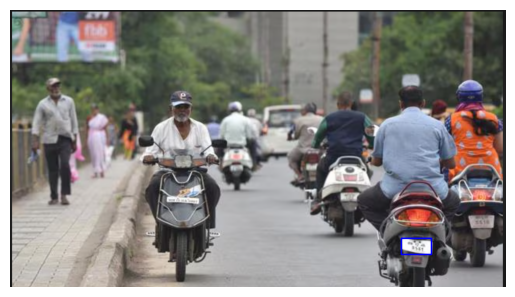

In [ ]:
# Install libraries
!pip install ultralytics pytesseract opencv-python

import cv2
import pytesseract
from ultralytics import YOLO
from google.colab import files
import matplotlib.pyplot as plt

# Load trained models
# Correcting the helmet model path
helmet_model = YOLO("/content/runs/detect/helmet_detection_yolov8/weights/best.pt")   # helmet model path
# Correcting the plate model path
plate_model = YOLO("/content/runs/detect/plate_detection_yolov83/weights/best.pt")  # plate model path

# Upload image manually
uploaded = files.upload()

for image_name in uploaded.keys():

    img = cv2.imread(image_name)

    # Run helmet detection
    helmet_results = helmet_model(img)

    without_helmet_detected = False

    for r in helmet_results:
        boxes = r.boxes
        for box in boxes:
            cls = int(box.cls)
            label = helmet_model.names[cls]

            if label == "without_helmet":
                without_helmet_detected = True

    # Run number plate detection if violation
    plate_text = ""

    if without_helmet_detected:
        plate_results = plate_model(img)

        for r in plate_results:
            for box in r.boxes:
                x1,y1,x2,y2 = map(int,box.xyxy[0])
                plate_crop = img[y1:y2,x1:x2]

                # OCR
                plate_text = pytesseract.image_to_string(plate_crop)
                print("Extracted Plate:", plate_text)

                cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

    # Show image
    img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis("off")

In [ ]:
!pip -q install ultralytics pytesseract opencv-python

import cv2
import pytesseract
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
import os, glob

In [ ]:
HELMET_BEST = "/content/runs/detect/helmet_detection_yolov8/weights/best.pt"
PLATE_BEST  = "/content/runs/detect/plate_detection_yolov83/weights/best.pt"

print("Helmet best exists:", os.path.exists(HELMET_BEST), HELMET_BEST)
print("Plate  best exists:", os.path.exists(PLATE_BEST), PLATE_BEST)

Helmet best exists: True /content/runs/detect/helmet_detection_yolov8/weights/best.pt
Plate  best exists: True /content/runs/detect/plate_detection_yolov83/weights/best.pt


In [ ]:
helmet_model = YOLO(HELMET_BEST)
plate_model  = YOLO(PLATE_BEST)

print("Helmet classes:", helmet_model.names)
print("Plate classes:", plate_model.names)

Helmet classes: {0: 'with_helmet', 1: 'without_helmet'}
Plate classes: {0: 'number_plate'}


In [ ]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print("Uploaded:", img_path)

Saving test3.png to test3.png
Uploaded: test3.png


Total Riders: 4
With Helmet: 3
Without Helmet: 1
Extracted Plate Texts: ['Pn']


(np.float64(-0.5), np.float64(954.5), np.float64(533.5), np.float64(-0.5))

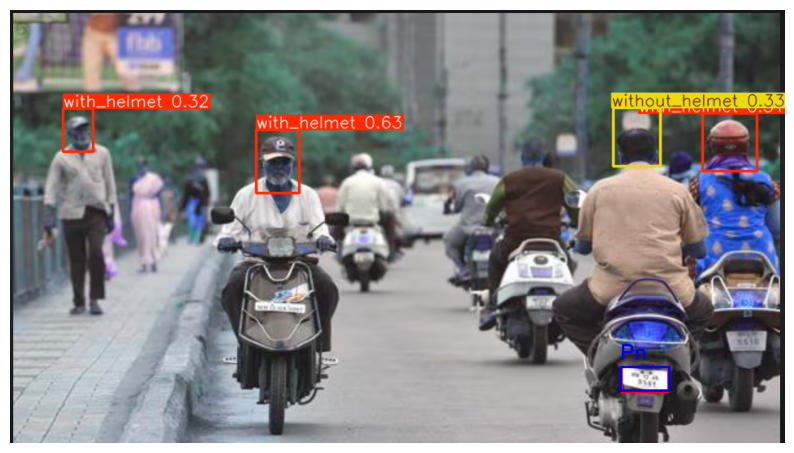

In [ ]:
# ----- HELMET DETECTION -----
helmet_res = helmet_model.predict(source=img, conf=0.25, verbose=False)[0]

with_helmet = 0
without_helmet = 0

# Draw detections from helmet model
annotated = helmet_res.plot()
annotated = cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)

for b in helmet_res.boxes:
    cls_id = int(b.cls[0])
    label = helmet_model.names[cls_id]

    if label == "with_helmet":
        with_helmet += 1

    elif label == "without_helmet":
        without_helmet += 1

# Total riders
rider_count = with_helmet + without_helmet

print("Total Riders:", rider_count)
print("With Helmet:", with_helmet)
print("Without Helmet:", without_helmet)

# ----- NUMBER PLATE DETECTION + OCR -----
plate_texts = []

if without_helmet > 0:

    plate_res = plate_model.predict(source=img, conf=0.25, verbose=False)[0]

    for pb in plate_res.boxes:
        x1, y1, x2, y2 = map(int, pb.xyxy[0])

        plate_crop = img[y1:y2, x1:x2]

        gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
        thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

        text = pytesseract.image_to_string(thresh, config="--psm 7")
        text = "".join(c for c in text if c.isalnum())

        if text != "":
            plate_texts.append(text)

        cv2.rectangle(annotated,(x1,y1),(x2,y2),(255,0,0),2)
        cv2.putText(annotated,text,(x1,y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,0.8,(255,0,0),2)

print("Extracted Plate Texts:", plate_texts)

# ----- SHOW FINAL OUTPUT -----
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [ ]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print("Uploaded:", img_path)

Saving test3.png to test3 (2).png
Uploaded: test3 (2).png


Total Riders: 4
With Helmet: 4
Without Helmet: 0
Extracted Plate Texts: []


(np.float64(-0.5), np.float64(1007.5), np.float64(568.5), np.float64(-0.5))

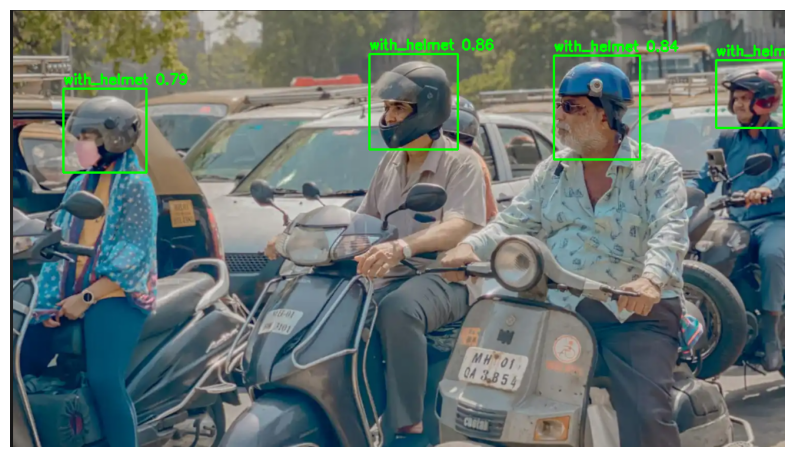

In [ ]:
import cv2, pytesseract, matplotlib.pyplot as plt

img = cv2.imread(img_path)

# ---------- HELMET DETECTION ----------
res = helmet_model.predict(img, conf=0.25, verbose=False)[0]

with_helmet = 0
without_helmet = 0

boxes = res.boxes

if boxes is not None:
    cls_ids = boxes.cls.cpu().numpy().astype(int)
    confs   = boxes.conf.cpu().numpy()
    coords  = boxes.xyxy.cpu().numpy()

    for cls_id, conf, (x1,y1,x2,y2) in zip(cls_ids, confs, coords):
        label = helmet_model.names[cls_id]

        if label == "with_helmet":
            with_helmet += 1
            color = (0,255,0)

        elif label == "without_helmet":
            without_helmet += 1
            color = (0,0,255)

        else:
            color = (255,255,0)

        x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])
        cv2.rectangle(img,(x1,y1),(x2,y2),color,2)
        cv2.putText(img,f"{label} {conf:.2f}",(x1,y1-6),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,color,2)

total_riders = with_helmet + without_helmet

print("Total Riders:", total_riders)
print("With Helmet:", with_helmet)
print("Without Helmet:", without_helmet)

# ---------- NUMBER PLATE + OCR ----------
plate_texts = []

if without_helmet > 0:
    pres = plate_model.predict(img, conf=0.25, verbose=False)[0]

    if pres.boxes is not None:
        pcoords = pres.boxes.xyxy.cpu().numpy()

        for (x1,y1,x2,y2) in pcoords:
            x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])
            crop = img[y1:y2, x1:x2]

            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            thr  = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

            text = pytesseract.image_to_string(thr, config="--psm 7")
            text = "".join(c for c in text if c.isalnum())

            if text:
                plate_texts.append(text)

            cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)
            cv2.putText(img,text,(x1,y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,0,0),2)

print("Extracted Plate Texts:", plate_texts)

# ---------- SHOW RESULT ----------
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")

In [ ]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print("Uploaded:", img_path)

Saving t1.png to t1 (1).png
Uploaded: t1 (1).png


Total Riders: 3
With Helmet: 2
Without Helmet: 1
Extracted Plate Texts: ['TSO8CX3444', 'igs233']


(np.float64(-0.5), np.float64(307.5), np.float64(305.5), np.float64(-0.5))

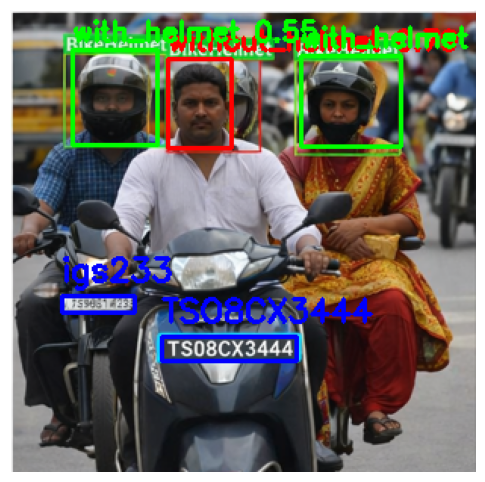

In [ ]:
import cv2, pytesseract, matplotlib.pyplot as plt

img = cv2.imread(img_path)

# ---------- HELMET DETECTION ----------
res = helmet_model.predict(img, conf=0.25, verbose=False)[0]

with_helmet = 0
without_helmet = 0

boxes = res.boxes

if boxes is not None:
    cls_ids = boxes.cls.cpu().numpy().astype(int)
    confs   = boxes.conf.cpu().numpy()
    coords  = boxes.xyxy.cpu().numpy()

    for cls_id, conf, (x1,y1,x2,y2) in zip(cls_ids, confs, coords):
        label = helmet_model.names[cls_id]

        if label == "with_helmet":
            with_helmet += 1
            color = (0,255,0)

        elif label == "without_helmet":
            without_helmet += 1
            color = (0,0,255)

        else:
            color = (255,255,0)

        x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])
        cv2.rectangle(img,(x1,y1),(x2,y2),color,2)
        cv2.putText(img,f"{label} {conf:.2f}",(x1,y1-6),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,color,2)

total_riders = with_helmet + without_helmet

print("Total Riders:", total_riders)
print("With Helmet:", with_helmet)
print("Without Helmet:", without_helmet)

# ---------- NUMBER PLATE + OCR ----------
plate_texts = []

if without_helmet > 0:
    pres = plate_model.predict(img, conf=0.25, verbose=False)[0]

    if pres.boxes is not None:
        pcoords = pres.boxes.xyxy.cpu().numpy()

        for (x1,y1,x2,y2) in pcoords:
            x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])
            crop = img[y1:y2, x1:x2]

            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            thr  = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

            text = pytesseract.image_to_string(thr, config="--psm 7")
            text = "".join(c for c in text if c.isalnum())

            if text:
                plate_texts.append(text)

            cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)
            cv2.putText(img,text,(x1,y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,0,0),2)

print("Extracted Plate Texts:", plate_texts)

# ---------- SHOW RESULT ----------
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")

In [ ]:
import os
import glob
import cv2
import pytesseract
import pandas as pd
from ultralytics import YOLO

# Dataset images folder
image_folder = "/content/drive/MyDrive/Helmet-Detection.v1i.yolov8/valid/images"

# Take first 10 images
images = glob.glob(image_folder + "/*.jpg")[:10]

data = []

for img_path in images:

    img = cv2.imread(img_path)

    with_helmet = 0
    without_helmet = 0
    plate_texts = []

    # Helmet detection
    res = helmet_model.predict(img, conf=0.25, verbose=False)[0]

    if res.boxes is not None:
        cls_ids = res.boxes.cls.cpu().numpy().astype(int)
        coords = res.boxes.xyxy.cpu().numpy()

        for cls_id,(x1,y1,x2,y2) in zip(cls_ids,coords):

            label = helmet_model.names[cls_id]

            if label == "with_helmet":
                with_helmet += 1

            elif label == "without_helmet":
                without_helmet += 1

                # Number plate detection
                plate_res = plate_model.predict(img, conf=0.25, verbose=False)[0]

                if plate_res.boxes is not None:

                    pcoords = plate_res.boxes.xyxy.cpu().numpy()

                    for (px1,py1,px2,py2) in pcoords:

                        crop = img[int(py1):int(py2), int(px1):int(px2)]

                        gray = cv2.cvtColor(crop,cv2.COLOR_BGR2GRAY)
                        text = pytesseract.image_to_string(gray,config="--psm 7")
                        text = "".join(c for c in text if c.isalnum())

                        if text != "":
                            plate_texts.append(text)

    total_riders = with_helmet + without_helmet

    data.append({
        "Image Name": os.path.basename(img_path),
        "Total Riders": total_riders,
        "With Helmet": with_helmet,
        "Without Helmet": without_helmet,
        "Plate Numbers": ",".join(plate_texts)
    })

# Convert to DataFrame
df = pd.DataFrame(data)

# Save to Excel
excel_path = "/content/helmet_violation_results.xlsx"
df.to_excel(excel_path, index=False)

print("Excel file saved at:", excel_path)
df

Excel file saved at: /content/helmet_violation_results.xlsx


,Image Name,Total Riders,With Helmet,Without Helmet,Plate Numbers
0,BikesHelmets197_png.rf.7174ff7273d3801f2b8d0d9...,1,0,1,
1,BikesHelmets563_png.rf.a02b43cb549677079dd6773...,2,1,1,Py
2,BikesHelmets707_png.rf.43bd6f6debd8e104509b6b6...,3,0,3,
3,BikesHelmets719_png.rf.106a6034a4a952b5d757178...,1,1,0,
4,BikesHelmets596_png.rf.60d11bb1574e9581eda7869...,6,4,2,
5,BikesHelmets57_png.rf.956a88735ea7c4c9a6ba4ed1...,1,0,1,
6,BikesHelmets344_png.rf.3a2dc01f58dabd0d7959f8e...,6,0,6,
7,BikesHelmets41_png.rf.1844ed07c6b63fb08f2311fc...,2,2,0,
8,BikesHelmets128_png.rf.d4b86b3041fd9da0e94a497...,1,0,1,
9,BikesHelmets70_png.rf.fe76b134ee10fcbfbe216c8f...,4,0,4,


In [ ]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print("Uploaded:", img_path)

Saving t3.png to t3 (1).png
Uploaded: t3 (1).png


Total Riders: 2
With Helmet: 0
Without Helmet: 2
Extracted Plate Texts: ['TN12DE6777']


(np.float64(-0.5), np.float64(314.5), np.float64(307.5), np.float64(-0.5))

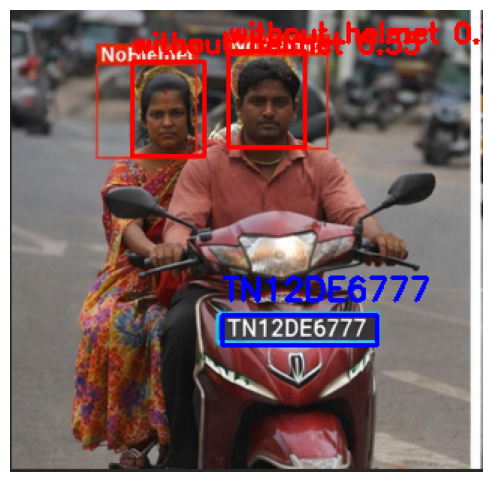

In [ ]:
import cv2, pytesseract, matplotlib.pyplot as plt

img = cv2.imread(img_path)

# ---------- HELMET DETECTION ----------
res = helmet_model.predict(img, conf=0.25, verbose=False)[0]

with_helmet = 0
without_helmet = 0

boxes = res.boxes

if boxes is not None:
    cls_ids = boxes.cls.cpu().numpy().astype(int)
    confs   = boxes.conf.cpu().numpy()
    coords  = boxes.xyxy.cpu().numpy()

    for cls_id, conf, (x1,y1,x2,y2) in zip(cls_ids, confs, coords):
        label = helmet_model.names[cls_id]

        if label == "with_helmet":
            with_helmet += 1
            color = (0,255,0)

        elif label == "without_helmet":
            without_helmet += 1
            color = (0,0,255)

        else:
            color = (255,255,0)

        x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])
        cv2.rectangle(img,(x1,y1),(x2,y2),color,2)
        cv2.putText(img,f"{label} {conf:.2f}",(x1,y1-6),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,color,2)

total_riders = with_helmet + without_helmet

print("Total Riders:", total_riders)
print("With Helmet:", with_helmet)
print("Without Helmet:", without_helmet)

# ---------- NUMBER PLATE + OCR ----------
plate_texts = []

if without_helmet > 0:
    pres = plate_model.predict(img, conf=0.25, verbose=False)[0]

    if pres.boxes is not None:
        pcoords = pres.boxes.xyxy.cpu().numpy()

        for (x1,y1,x2,y2) in pcoords:
            x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])
            crop = img[y1:y2, x1:x2]

            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            thr  = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

            text = pytesseract.image_to_string(thr, config="--psm 7")
            text = "".join(c for c in text if c.isalnum())

            if text:
                plate_texts.append(text)

            cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)
            cv2.putText(img,text,(x1,y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,0,0),2)

print("Extracted Plate Texts:", plate_texts)

# ---------- SHOW RESULT ----------
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")

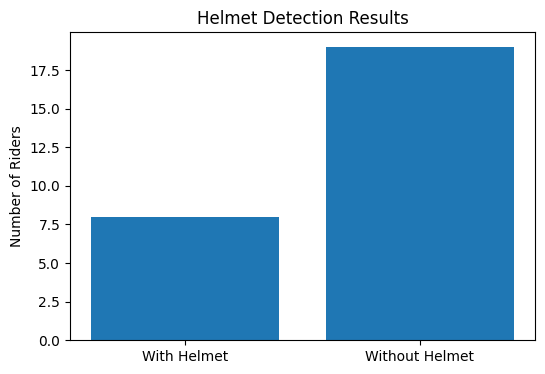

In [ ]:
import matplotlib.pyplot as plt

total_with = df["With Helmet"].sum()
total_without = df["Without Helmet"].sum()

labels = ["With Helmet", "Without Helmet"]
values = [total_with, total_without]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Helmet Detection Results")
plt.ylabel("Number of Riders")
plt.show()

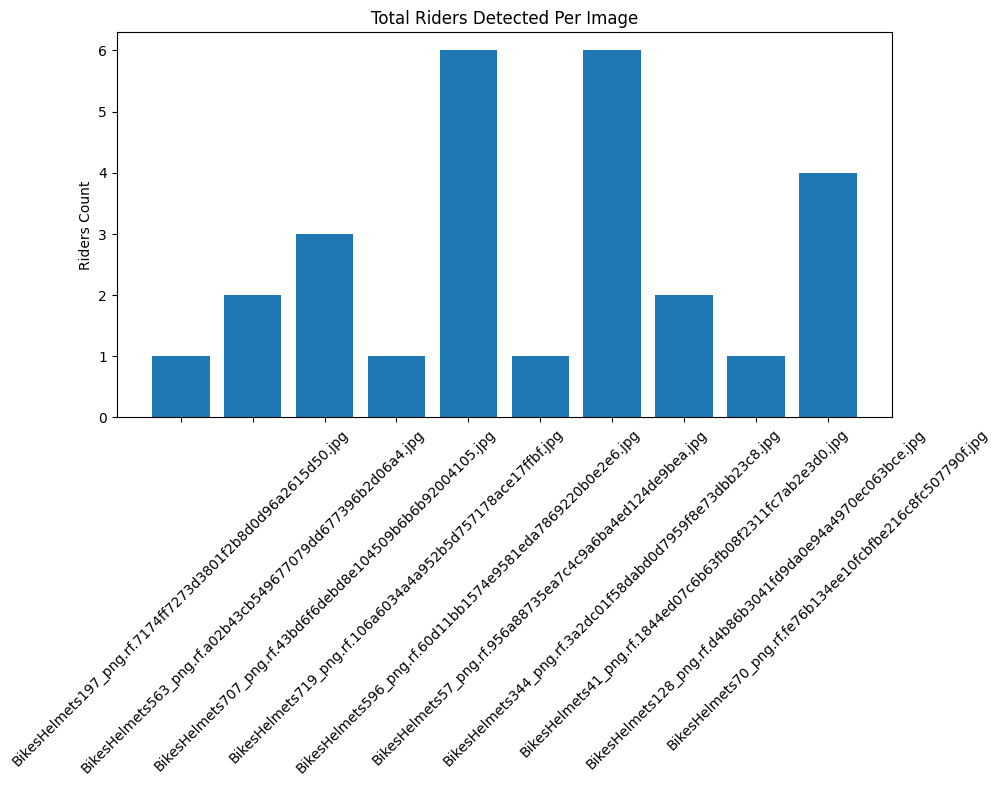

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(df["Image Name"], df["Total Riders"])
plt.xticks(rotation=45)
plt.title("Total Riders Detected Per Image")
plt.ylabel("Riders Count")
plt.show()

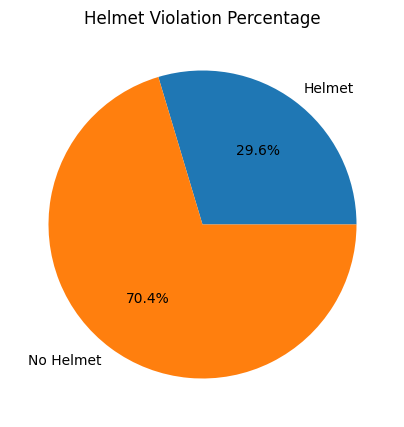

In [ ]:
sizes = [total_with, total_without]
labels = ["Helmet", "No Helmet"]

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Helmet Violation Percentage")
plt.show()

## Check Distribution of Helmet vs. No-Helmet Instances

This cell will iterate through all YOLO label files (`.txt`) in both the training and validation directories of your helmet detection dataset. It will then count the occurrences of 'with_helmet' and 'without_helmet' classes to show their distribution.

In [ ]:
import os
import glob
from collections import defaultdict

HELMET_DETECTION_DATASET_PATH = '/content/drive/MyDrive/Helmet-Detection.v1i.yolov8'

# Assuming YOLOv8 class mapping: 0: 'with_helmet', 1: 'without_helmet'
# This can be verified from the model.names or data.yaml used during training
class_map = {0: 'with_helmet', 1: 'without_helmet'}

instance_counts = defaultdict(int)

# Paths to train and valid label directories
train_labels_path = os.path.join(HELMET_DETECTION_DATASET_PATH, 'train', 'labels')
val_labels_path = os.path.join(HELMET_DETECTION_DATASET_PATH, 'valid', 'labels')

print("Analyzing label files...")

for label_dir in [train_labels_path, val_labels_path]:
    if not os.path.exists(label_dir):
        print(f"Warning: Label directory not found: {label_dir}. Skipping.")
        continue

    label_files = glob.glob(os.path.join(label_dir, '*.txt'))
    print(f"Found {len(label_files)} label files in {label_dir}")

    for label_file in label_files:
        try:
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_id = int(parts[0])
                        if class_id in class_map:
                            instance_counts[class_map[class_id]] += 1
                        else:
                            print(f"Warning: Unknown class ID {class_id} in {label_file}")
        except Exception as e:
            print(f"Error reading {label_file}: {e}")

print("\n--- Instance Distribution Summary ---")
total_instances = sum(instance_counts.values())

if total_instances > 0:
    for class_name, count in instance_counts.items():
        percentage = (count / total_instances) * 100
        print(f"{class_name.replace('_', ' ').title()}: {count} instances ({percentage:.2f}%)")
else:
    print("No instances found in label files.")


Analyzing label files...
Found 437 label files in /content/drive/MyDrive/Helmet-Detection.v1i.yolov8/train/labels
Found 123 label files in /content/drive/MyDrive/Helmet-Detection.v1i.yolov8/valid/labels

--- Instance Distribution Summary ---
With Helmet: 694 instances (67.12%)
Without Helmet: 340 instances (32.88%)


## Displaying Model Performance Metrics

This section explicitly runs the `.val()` method on both the trained helmet detection and number plate detection models to compute and display their performance metrics (Precision, Recall, mAP50, mAP50-95) on their respective validation sets.

In [ ]:
import os
from ultralytics import YOLO

HELMET_BEST_PATH = '/content/runs/detect/helmet_detection_yolov8/weights/best.pt'
PLATE_BEST_PATH = '/content/runs/detect/plate_detection_yolov83/weights/best.pt'

# Load models if not already loaded
if 'helmet_model' not in locals() or 'number_plate_model' not in locals():
    print("Loading models...")
    helmet_model = YOLO(HELMET_BEST_PATH)
    number_plate_model = YOLO(PLATE_BEST_PATH)
    print("Models loaded.")

# ---------------- HELMET MODEL ----------------
print("\n--- Evaluating Helmet Detection Model ---")
helmet_metrics = helmet_model.val()

precision = helmet_metrics.results_dict.get('metrics/precision(B)',0)
recall = helmet_metrics.results_dict.get('metrics/recall(B)',0)
map50 = helmet_metrics.results_dict.get('metrics/mAP50(B)',0)
map95 = helmet_metrics.results_dict.get('metrics/mAP50-95(B)',0)

# Accuracy approximation
accuracy = (2 * precision * recall) / (precision + recall + 1e-6)

print("\nHelmet Detection Model Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"mAP50 (Detection Accuracy): {map50:.4f}")
print(f"mAP50-95: {map95:.4f}")
print(f"Approx Accuracy (F1 based): {accuracy:.4f}")

# Per class AP
if hasattr(helmet_metrics,'box') and helmet_metrics.box.ap is not None:
    print("\nPer-Class mAP (Helmet Model):")
    for i,ap in enumerate(helmet_metrics.box.ap):
        if i < len(helmet_model.names):
            print(f"{helmet_model.names[i]}: {ap:.4f}")

# ---------------- NUMBER PLATE MODEL ----------------
print("\n--- Evaluating Number Plate Detection Model ---")
number_plate_metrics = number_plate_model.val()

precision = number_plate_metrics.results_dict.get('metrics/precision(B)',0)
recall = number_plate_metrics.results_dict.get('metrics/recall(B)',0)
map50 = number_plate_metrics.results_dict.get('metrics/mAP50(B)',0)
map95 = number_plate_metrics.results_dict.get('metrics/mAP50-95(B)',0)

accuracy = (2 * precision * recall) / (precision + recall + 1e-6)

print("\nNumber Plate Detection Model Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"mAP50 (Detection Accuracy): {map50:.4f}")
print(f"mAP50-95: {map95:.4f}")
print(f"Approx Accuracy (F1 based): {accuracy:.4f}")

# Per class AP
if hasattr(number_plate_metrics,'box') and number_plate_metrics.box.ap is not None:
    print("\nPer-Class mAP (Number Plate Model):")
    for i,ap in enumerate(number_plate_metrics.box.ap):
        if i < len(number_plate_model.names):
            print(f"{number_plate_model.names[i]}: {ap:.4f}")


--- Evaluating Helmet Detection Model ---
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 5.7±11.6 ms, read: 5.5±4.7 MB/s, size: 33.2 KB)
val: Scanning /content/drive/MyDrive/Helmet-Detection.v1i.yolov8/valid/labels.cache... 123 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 25.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.1it/s 7.6s
                   all        123        234      0.672      0.743      0.751      0.441
           with_helmet         81        147      0.743       0.83      0.861      0.541
        without_helmet         49         87      0.601      0.655      0.641       0.34
Speed: 13.1ms preprocess, 7.1ms inference, 0.0ms loss, 6.4ms postprocess per image
Results saved to /content/runs/detect/val5

Helmet Detection Model Metrics:
Precision: 0.6722
Recall: 0.7426
mAP50 (Detection Accuracy): 0.7512
mAP50-95:

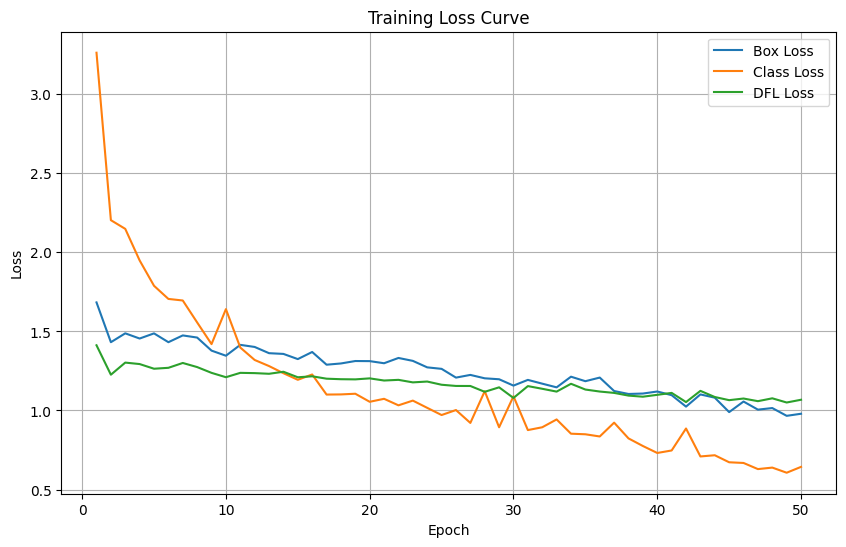

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to training results
results_path = "/content/runs/detect/helmet_detection_yolov8/results.csv"

# Load CSV
df = pd.read_csv(results_path)

# Plot training losses
plt.figure(figsize=(10,6))

plt.plot(df['epoch'], df['train/box_loss'], label='Box Loss')
plt.plot(df['epoch'], df['train/cls_loss'], label='Class Loss')
plt.plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid()

plt.show()

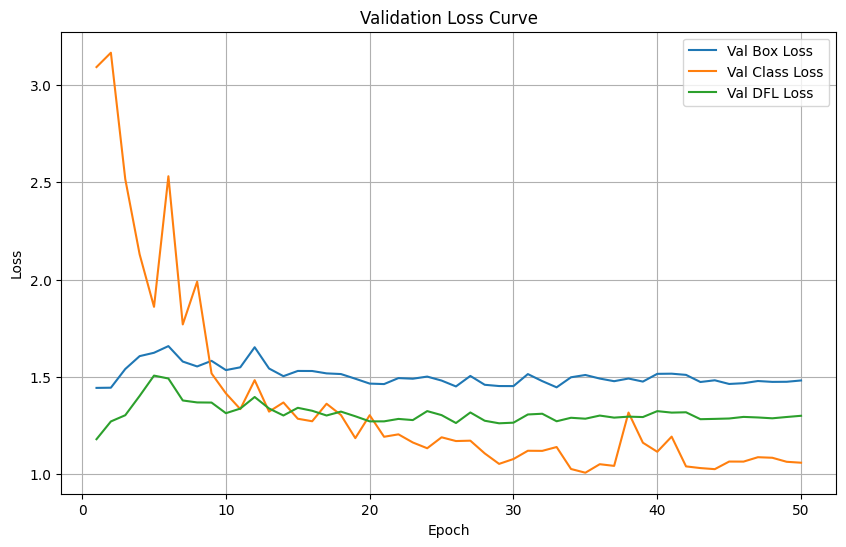

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
plt.plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss')
plt.plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Curve")
plt.legend()
plt.grid()

plt.show()

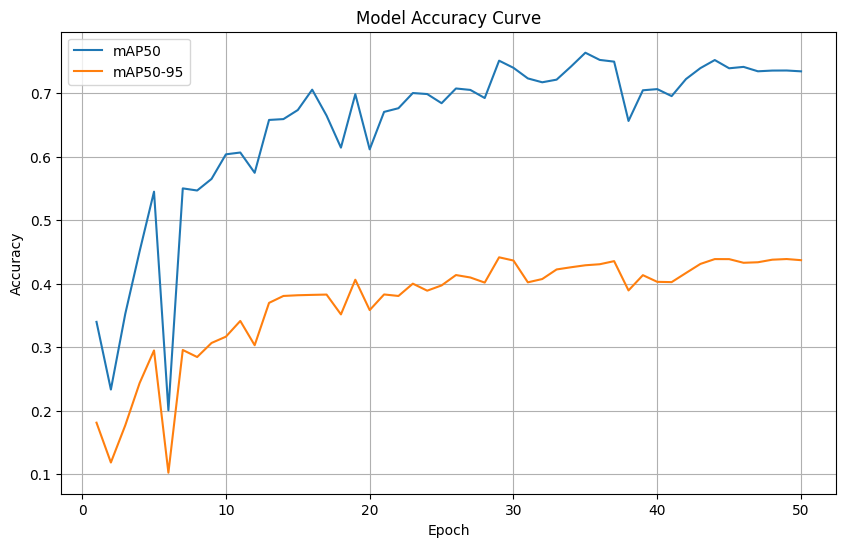

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Curve")
plt.legend()
plt.grid()

plt.show()